In [2]:
import astropy
import numpy as np
from pathlib import Path
from astropy.nddata import CCDData
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import warnings
import glob

In [33]:
#PIC = fits.util.get_testdata_filepath('data/LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits')
PIC = fits.open('data/LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits') #see group projects canvas page
#headers = np.asarray(PIC[1].header)
data = np.asarray(PIC[1].data)
print(f"{len(data["PICid"])} entries")

309787 entries


In [34]:
myepictable = []

for i in range(len(data["Mass"])):
    if data["Mass"][i] < 1.5:
        myepictable.append(data[i])

data_reduced = np.asarray(myepictable)

In [35]:
print(f"{data_reduced["Mass"][0]} solar masses, {data_reduced["Radius"][0]} solar radii, {data_reduced["Teff"][0]} K")

0.553082617452391 solar masses, 0.528597868558916 solar radii, 3706.57015580926 K


In [82]:
#M = data_reduced["Mass"] #grabs the masses of the relevent stars in PIC, in solar masses
#R = data_reduced["Radius"] #grabs the radii of the relevent stars in PIC, in solar radii
#T = data_reduced["Teff"] #grabs the temperatures of the relevent stars in PIC, in Kelvin

def max_freq(M, R, T):
    dT = T / 5778 
    return( float(M * R**(-2) * dT**(-0.5)) ) #returns max frequency in terms of max frequency of the Sun

def tau_gran(M, R, T):
    tau_gran_sun = 250 #characteristic timescale of granulation for the Sun
    return( float( ( max_freq(M, R, T) )**(-1) * tau_gran_sun) ) #returns the characteristic timescale of granulation for the star

def lumin(M, R, T):    
    solar_lum = 3.828 * 10**26
    return( float(M**4 * solar_lum) ) #returns luminosity in Watts, using the mass-luminosity relation

def granulation_amplitude(M, R, T):
    solar_max_freq = 3100 * 10**-6
    return( float((lumin(M, R, T)**2 * max_freq(M, R, T) * solar_max_freq) / ((M)**3 * T**5.5)) ) #1.989*10**30, 3.828 * 10**26

def power_spec_granulation(M, R, T, freq):
    return( ( 4 * granulation_amplitude(M, R, T)**2 * tau_gran(M, R, T) ) / (1 + (2 * np.pi * freq * tau_gran(M, R, T))**2 ) )

2206.09404665413
351.29961987586285
1.2482453280009997


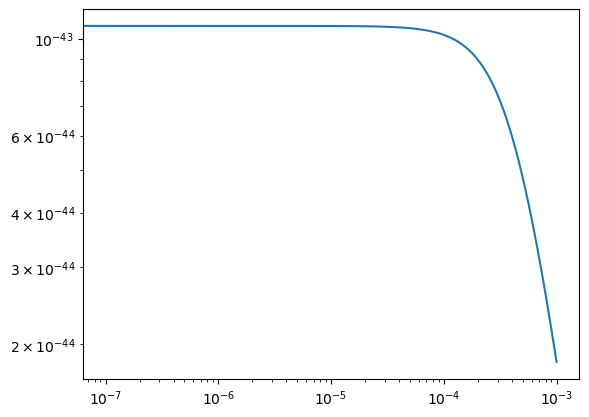

In [83]:
f = np.linspace(0, 10**-3, 10000)
P = power_spec_granulation(1.057, 1.216, 5830, f)

print( max_freq(1.057, 1.216, 5830) * 3100 )
print( tau_gran(1.057, 1.216, 5830) )
print( lumin(1.057, 1.216, 5830) / (3.828 * 10**26) )

plt.loglog(f, P)
plt.show()